In [309]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [310]:
data = pd.read_csv("housing.csv")

In [311]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [312]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [313]:
data.dropna(inplace=True)

In [314]:
data.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [315]:
from sklearn.model_selection import train_test_split

X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

In [316]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [317]:
train_data = X_train.join(y_train)

In [318]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
16931,-122.31,37.57,42.0,3157.0,676.0,1603.0,629.0,3.7422,NEAR OCEAN,292600.0
4001,-118.65,34.18,26.0,4607.0,656.0,1769.0,643.0,7.4918,<1H OCEAN,367600.0
17217,-119.70,34.43,39.0,1486.0,467.0,758.0,409.0,2.6875,<1H OCEAN,320600.0
10137,-117.89,33.91,33.0,1264.0,224.0,527.0,227.0,3.7321,<1H OCEAN,216500.0
16200,-121.27,37.95,52.0,1318.0,308.0,1368.0,310.0,1.8261,INLAND,54600.0
...,...,...,...,...,...,...,...,...,...,...
7662,-118.22,33.83,44.0,1792.0,404.0,1115.0,358.0,3.9091,<1H OCEAN,174400.0
6574,-118.16,34.20,43.0,1810.0,343.0,988.0,307.0,3.8203,<1H OCEAN,176000.0
13783,-117.06,34.03,27.0,1945.0,446.0,859.0,418.0,1.5203,INLAND,126200.0
18057,-122.00,37.27,33.0,1664.0,271.0,759.0,272.0,5.7876,<1H OCEAN,415800.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

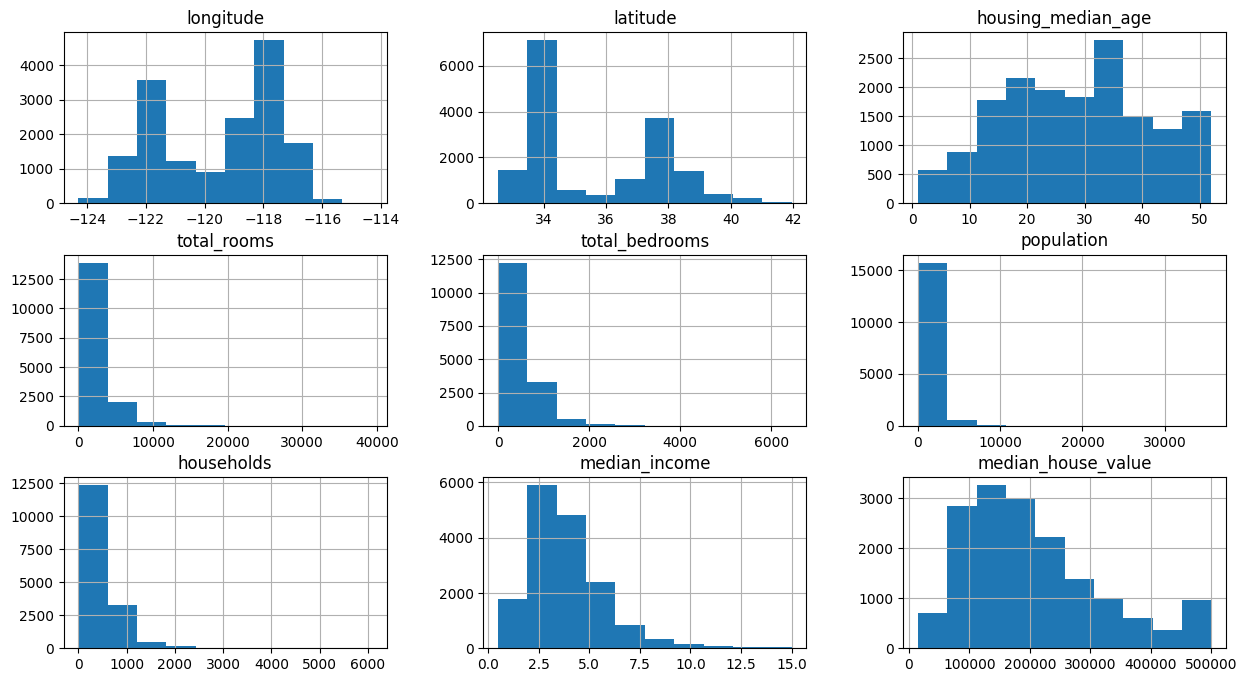

In [319]:
train_data.hist(figsize=(15,8))

In [320]:
train_data_numeric = train_data.drop('ocean_proximity', axis=1)

<Axes: >

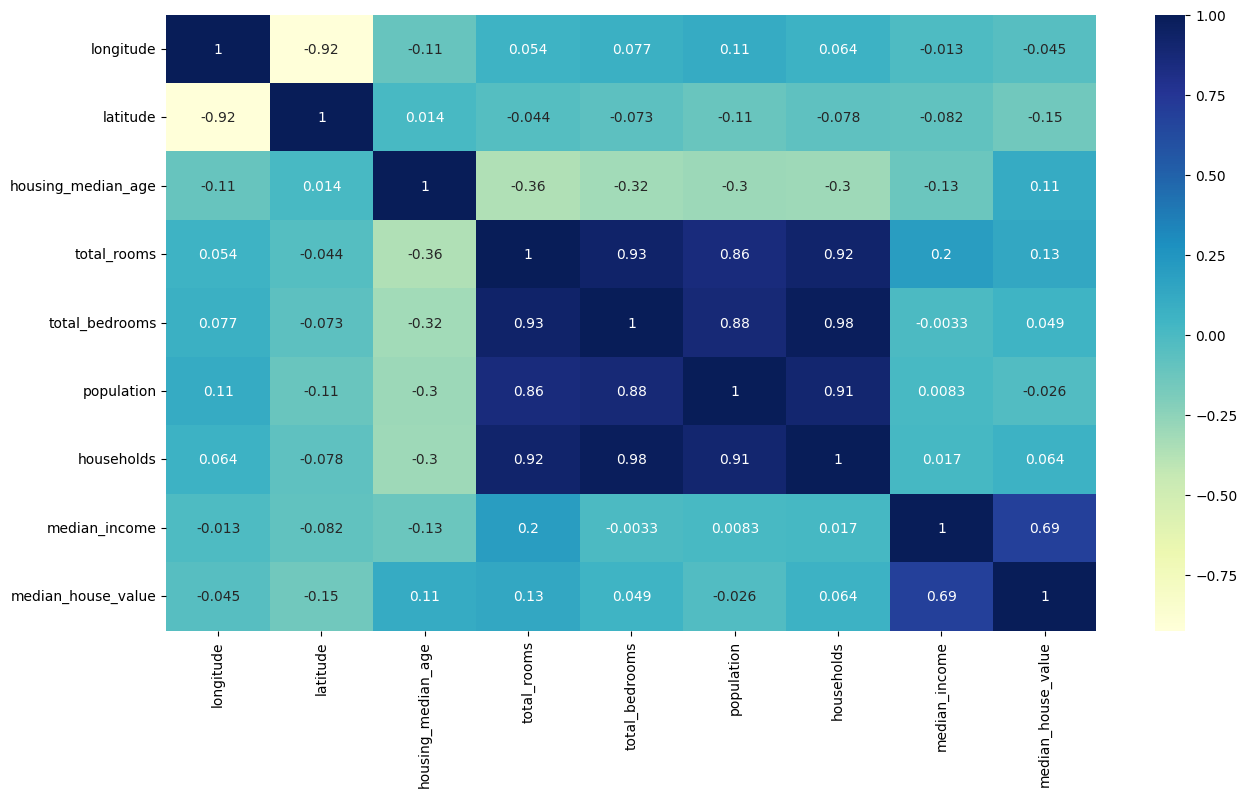

In [321]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data_numeric.corr(), annot=True, cmap="YlGnBu")

## Data Preprocessing

In [322]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)                                   

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

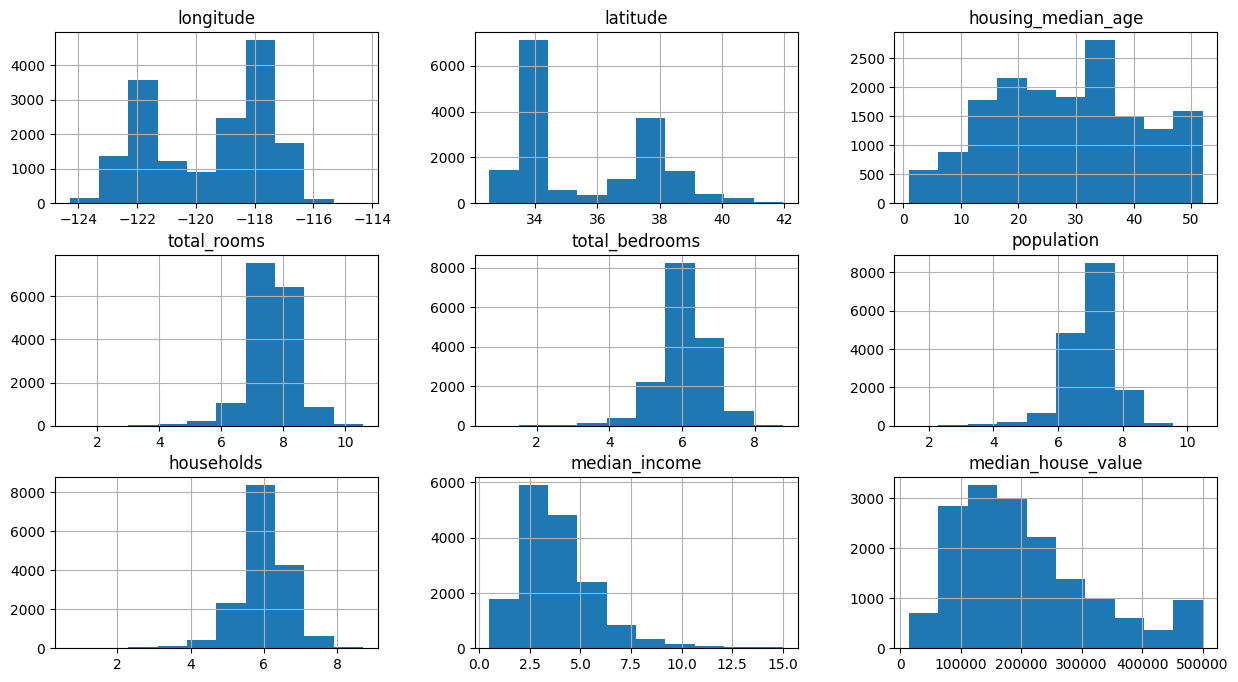

In [323]:
train_data.hist(figsize=(15,8))

In [324]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop('ocean_proximity', axis=1)

In [325]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
16931,-122.31,37.57,42.0,8.057694,6.517671,7.380256,6.445720,3.7422,292600.0,False,False,False,False,True
4001,-118.65,34.18,26.0,8.435549,6.487684,7.478735,6.467699,7.4918,367600.0,True,False,False,False,False
17217,-119.70,34.43,39.0,7.304516,6.148468,6.632002,6.016157,2.6875,320600.0,True,False,False,False,False
10137,-117.89,33.91,33.0,7.142827,5.416100,6.269096,5.429346,3.7321,216500.0,True,False,False,False,False
16200,-121.27,37.95,52.0,7.184629,5.733341,7.221836,5.739793,1.8261,54600.0,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7662,-118.22,33.83,44.0,7.491645,6.003887,7.017506,5.883322,3.9091,174400.0,True,False,False,False,False
6574,-118.16,34.20,43.0,7.501634,5.840642,6.896694,5.730100,3.8203,176000.0,True,False,False,False,False
13783,-117.06,34.03,27.0,7.573531,6.102559,6.756932,6.037871,1.5203,126200.0,False,True,False,False,False
18057,-122.00,37.27,33.0,7.417580,5.605802,6.633318,5.609472,5.7876,415800.0,True,False,False,False,False


<Axes: >

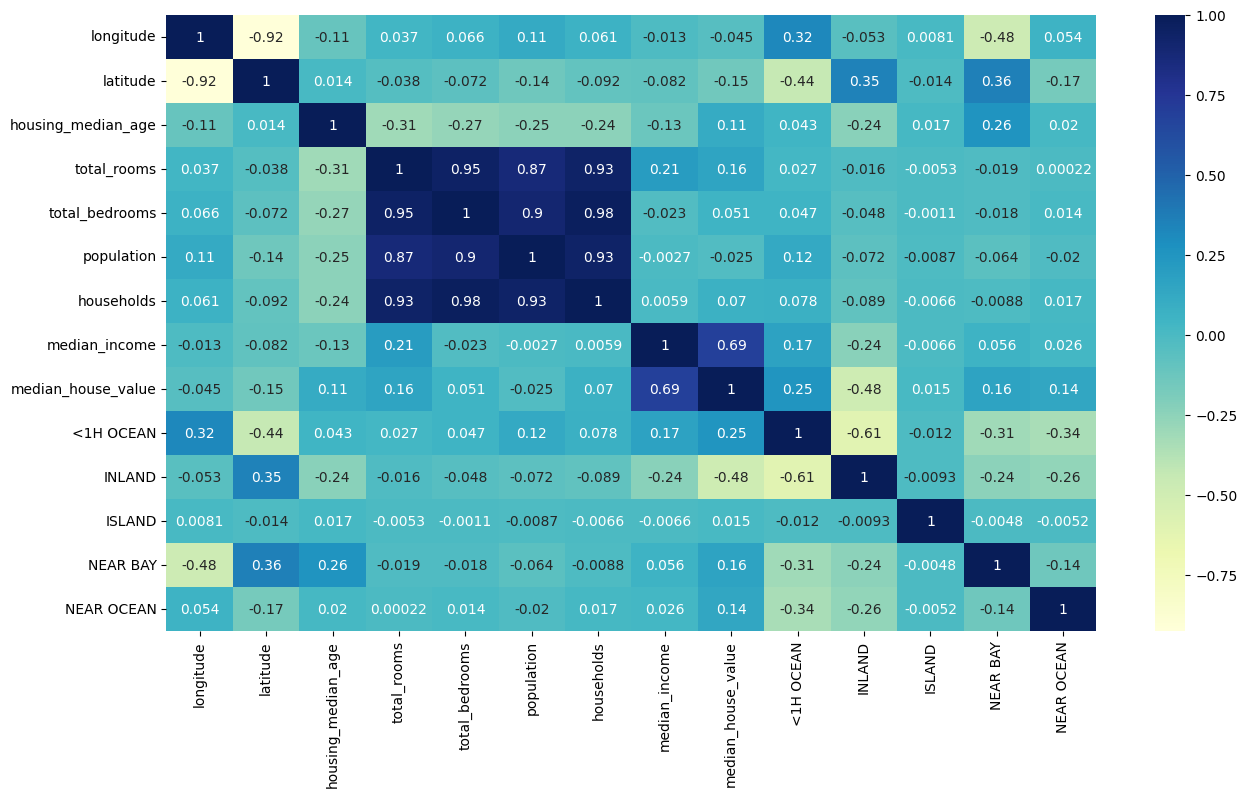

In [326]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

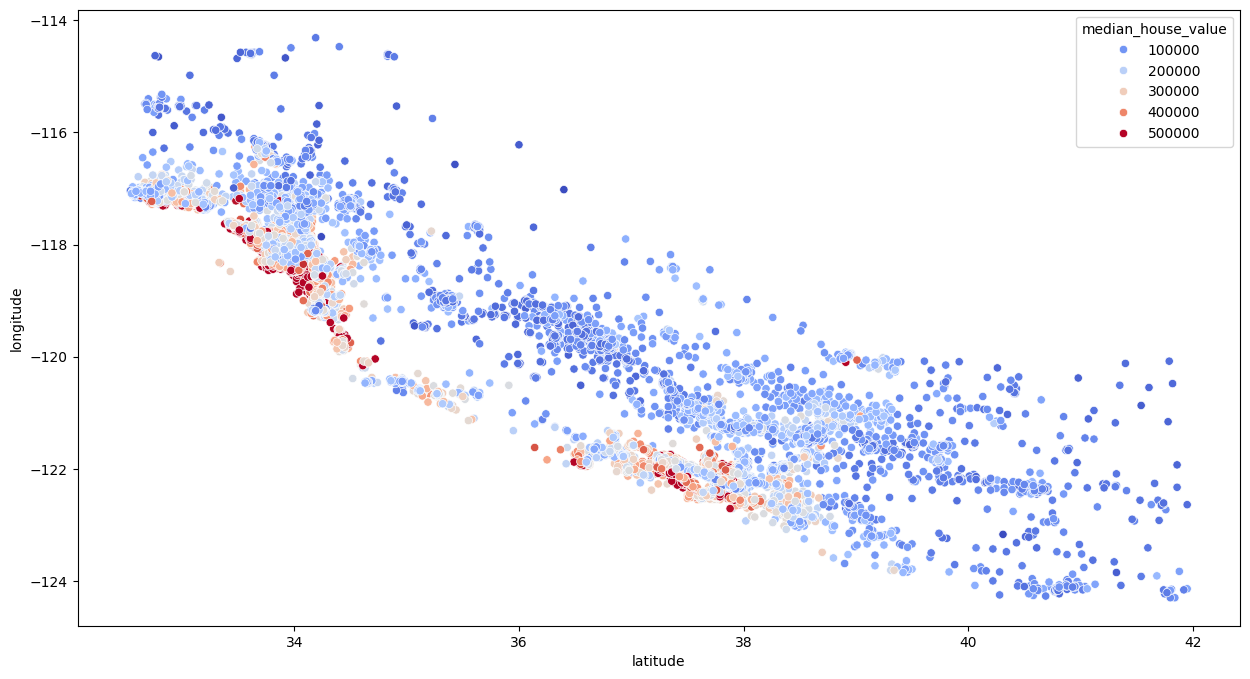

In [327]:
plt.figure(figsize=(15,8))
sns.scatterplot(x="latitude", y="longitude", data= train_data, hue="median_house_value", palette="coolwarm")

In [328]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']
train_data['population_per_household'] = train_data['population'] / train_data['households']
train_data['income_bedroom_interaction'] = train_data['median_income'] * train_data['bedroom_ratio']


<Axes: >

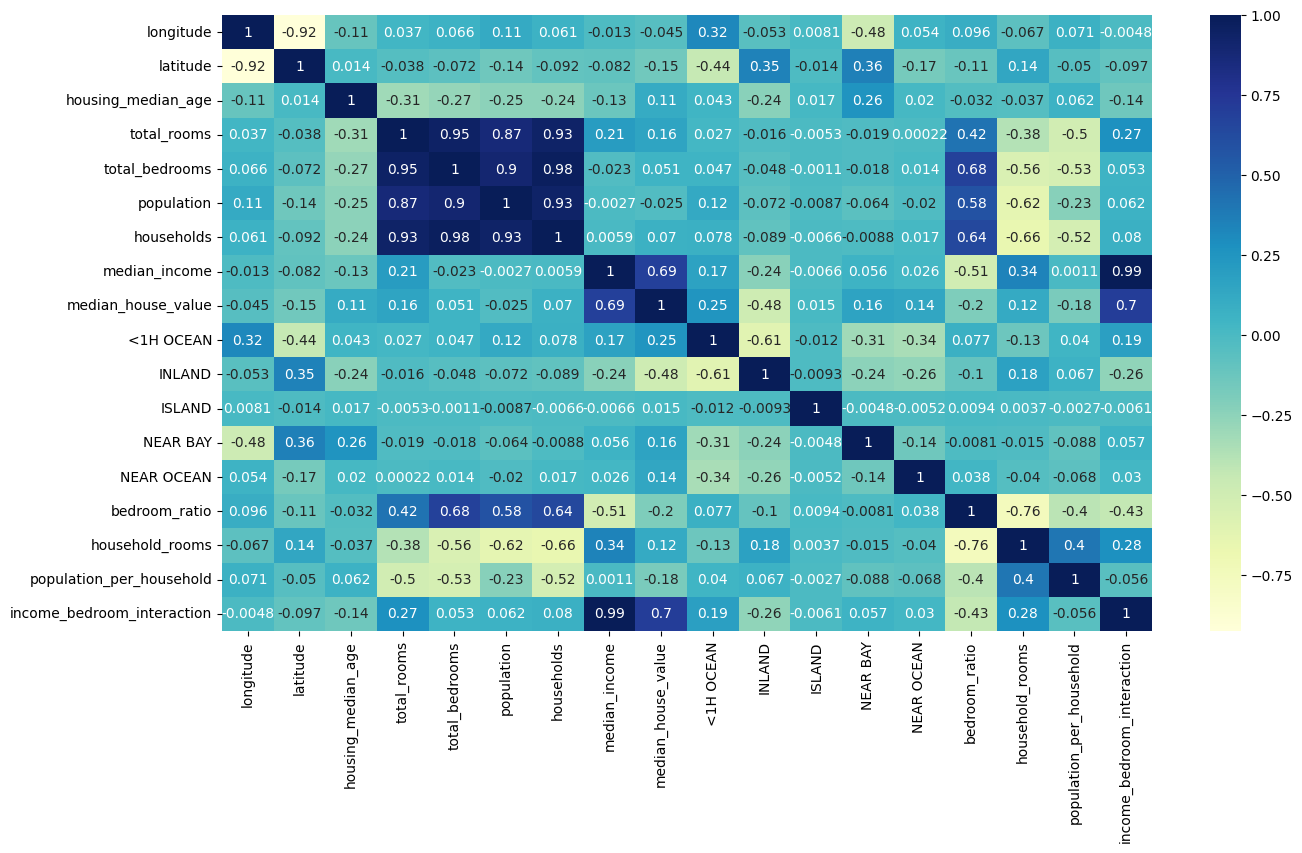

In [329]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

In [330]:
train_data.corr()['median_house_value'].sort_values(ascending=False)

median_house_value            1.000000
income_bedroom_interaction    0.699917
median_income                 0.686520
<1H OCEAN                     0.254850
NEAR BAY                      0.163387
total_rooms                   0.155596
NEAR OCEAN                    0.142698
household_rooms               0.119693
housing_median_age            0.105712
households                    0.070358
total_bedrooms                0.051461
ISLAND                        0.014980
population                   -0.025238
longitude                    -0.045025
latitude                     -0.145398
population_per_household     -0.180947
bedroom_ratio                -0.198718
INLAND                       -0.484713
Name: median_house_value, dtype: float64

In [331]:
from sklearn.linear_model import LinearRegression

X_train, y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']

reg = LinearRegression()

reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [332]:
test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1) 

# test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop('ocean_proximity', axis=1)

test_data = test_data.reindex(columns=train_data.columns, fill_value=0)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']
test_data['population_per_household'] = test_data['population'] / test_data['households']
test_data['income_bedroom_interaction'] = test_data['median_income'] * test_data['bedroom_ratio']


In [333]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms,population_per_household,income_bedroom_interaction
14650,-117.20,32.77,31.0,7.577122,6.156979,6.842683,6.137727,2.8621,196900.0,0,0,0,0,0,0.812575,1.234516,1.114856,2.325671
16868,-122.39,37.60,36.0,7.479300,6.214608,7.111512,6.131226,2.5600,273100.0,0,0,0,0,0,0.830908,1.219870,1.159884,2.127124
18643,-121.99,36.98,19.0,8.633019,7.186901,8.012681,7.145984,3.1914,215600.0,0,0,0,0,0,0.832490,1.208094,1.121284,2.656808
7599,-118.25,33.89,36.0,6.008813,4.276666,5.594711,4.356709,3.9000,115800.0,0,0,0,0,0,0.711732,1.379209,1.284160,2.775756
9142,-117.89,34.49,12.0,8.146130,6.395262,7.315218,6.293419,3.7043,150800.0,0,0,0,0,0,0.785068,1.294388,1.162360,2.908126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9409,-122.53,37.89,35.0,8.325548,6.536692,7.375882,6.562444,5.9073,400400.0,0,0,0,0,0,0.785136,1.268666,1.123954,4.638037
13389,-117.58,34.10,4.0,8.757941,7.368340,8.119696,7.242082,3.5186,127800.0,0,0,0,0,0,0.841332,1.209313,1.121183,2.960312
4308,-118.31,34.09,42.0,7.576610,6.741701,7.824446,6.701960,1.5195,218200.0,0,0,0,0,0,0.889804,1.130507,1.167486,1.352058
3953,-118.65,34.21,5.0,8.599694,6.501290,7.747597,6.533789,9.6465,500001.0,0,0,0,0,0,0.755991,1.316188,1.185774,7.292665


In [334]:
X_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']


In [335]:
reg.score(X_test, y_test)

0.6395196871688937

In [338]:
new_data = pd.DataFrame({
    'longitude': [-117.88],
    'latitude': [33.85],
    'housing_median_age': [26.0],
    'total_rooms': [8.275122],
    'total_bedrooms': [6.661855],
    'population': [7.754910],
    'households': [6.587550],
    'median_income': [3.7772],
    # Ocean proximity one-hot (same columns as train)
    '<1H OCEAN': [0],
    'INLAND': [0],
    'ISLAND': [0],
    'NEAR BAY': [0],
    'NEAR OCEAN': [0],
})

# Align columns (VERY IMPORTANT)
new_data = new_data.reindex(columns=train_data.drop('median_house_value', axis=1).columns, fill_value=0)

# Predict
predicted_price = reg.predict(new_data)
print("Predicted value:", predicted_price[0])

Predicted value: 120336.3003713463
